3 years window processed...
5 years window processed...
7 years window processed...
9 years window processed...
11 years window processed...
13 years window processed...
15 years window processed...

=== Summary of All Methods ===
   window_years  Method1_Snapshot_Default  Method1_Snapshot_Prepay  \
0             3                    0.0005                   0.0030   
1             5                    0.0005                   0.0029   
2             7                    0.0005                   0.0029   
3             9                    0.0005                   0.0029   
4            11                    0.0005                   0.0029   
5            13                    0.0005                   0.0028   
6            15                    0.0005                   0.0028   

   Method2_Unique_Default  Method2_Unique_Prepay  Method3_KM_Default  \
0                  0.0142                 0.0933              0.1020   
1                  0.0225                 0.1371              0.

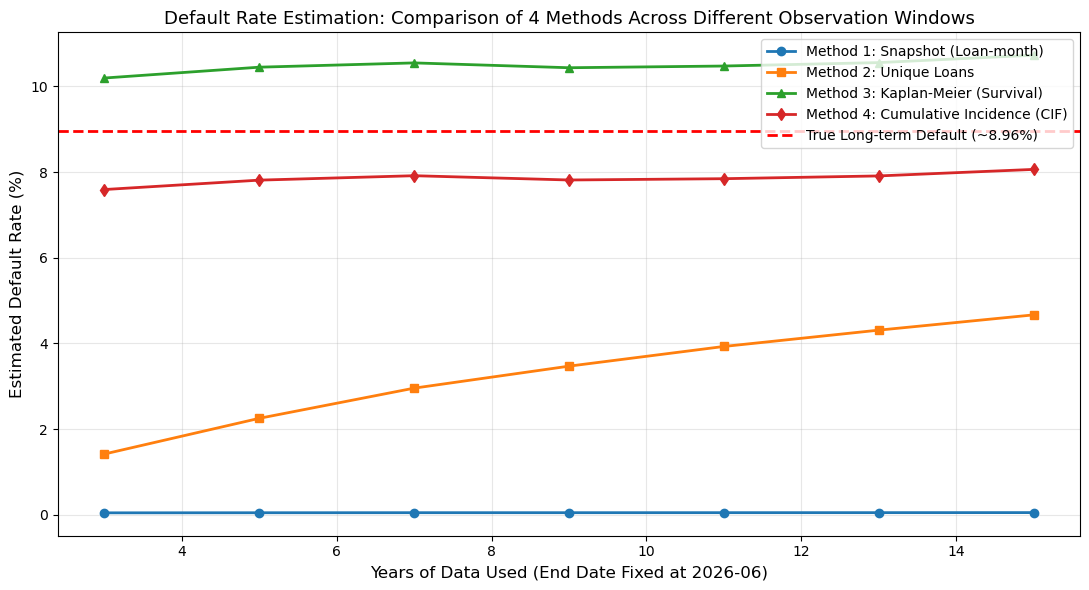

✅ Prepay plot saved as: prepay_rate_comparison.png


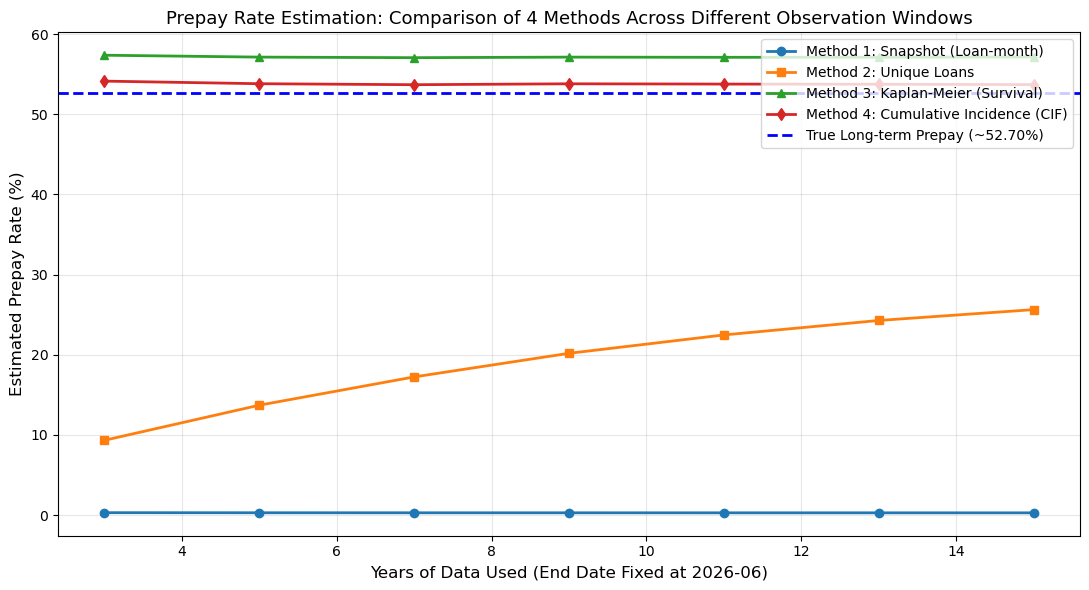

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ====================== 1. Load Data ======================
panel = pd.read_csv('mortgage_panel.csv')
panel['current_date'] = pd.to_datetime(panel['current_date'])
panel['issue_date'] = pd.to_datetime(panel['issue_date'])

end_date = pd.Timestamp('2026-06-30')

# ====================== 2. Helper Function: Manual Competing Risks ======================
def calculate_manual_competing_risks(df):
    """Returns key metrics using your manual age_table logic"""
    
    age_table = df.groupby('age').agg(
        total_at_risk=('loan_id', 'count'),
        num_default=('status', lambda x: (x == 2).sum()),
        num_prepay=('status', lambda x: (x == 1).sum()),
        num_terminate=('status', lambda x: x.isin([1, 2]).sum())
    ).reset_index()

    age_table['default_hazard'] = age_table['num_default'] / age_table['total_at_risk']
    age_table['prepay_hazard'] = age_table['num_prepay'] / age_table['total_at_risk']
    age_table['terminate_hazard'] = age_table['num_terminate'] / age_table['total_at_risk']

    age_table = age_table.sort_values('age').reset_index(drop=True)

    # Survival functions
    age_table['survival_default'] = 1.0
    age_table['survival_prepay'] = 1.0
    age_table['survival_overall'] = 1.0

    for i in range(1, len(age_table)):
        age_table.loc[i, 'survival_default'] = (
            age_table.loc[i-1, 'survival_default'] * (1 - age_table.loc[i, 'default_hazard']))
        age_table.loc[i, 'survival_prepay'] = (
            age_table.loc[i-1, 'survival_prepay'] * (1 - age_table.loc[i, 'prepay_hazard']))
        age_table.loc[i, 'survival_overall'] = (
            age_table.loc[i-1, 'survival_overall'] * (1 - age_table.loc[i, 'terminate_hazard']))

    # CIF
    age_table['CIF_default'] = age_table['default_hazard']
    age_table['CIF_prepay'] = age_table['prepay_hazard']

    for i in range(1, len(age_table)):
        age_table.loc[i, 'CIF_default'] = (
            age_table.loc[i-1, 'CIF_default'] + 
            age_table.loc[i-1, 'survival_overall'] * age_table.loc[i, 'default_hazard'])
        age_table.loc[i, 'CIF_prepay'] = (
            age_table.loc[i-1, 'CIF_prepay'] + 
            age_table.loc[i-1, 'survival_overall'] * age_table.loc[i, 'prepay_hazard'])

    # Take value at the end of the window (or closest to age 240)
    final_age = min(240, age_table['age'].max())
    final_row = age_table[age_table['age'] == final_age].iloc[0]

    return {
        'Method3_KM_Default': 1 - final_row['survival_default'],
        'Method3_KM_Prepay': 1 - final_row['survival_prepay'],
        'Method4_CIF_Default': final_row['CIF_default'],
        'Method4_CIF_Prepay': final_row['CIF_prepay']
    }

# ====================== 3. Main Function for All 4 Methods ======================
def calculate_all_methods(panel, start_date, end_date, years):
    df = panel[(panel['current_date'] >= start_date) & (panel['current_date'] <= end_date)].copy()
    
    if len(df) == 0:
        return None
    
    results = {'window_years': years}
    
    # --- Method 1: Snapshot (Loan-month records) ---
    total_records = len(df)
    results['Method1_Snapshot_Default'] = (df['status'] == 2).sum() / total_records
    results['Method1_Snapshot_Prepay']  = (df['status'] == 1).sum() / total_records
    
    # --- Method 2: Unique Loans ---
    final = df.groupby('loan_id').last().reset_index()
    total_loans = len(final)
    results['Method2_Unique_Default'] = (final['status'] == 2).sum() / total_loans
    results['Method2_Unique_Prepay']  = (final['status'] == 1).sum() / total_loans

    # Methods 3 & 4: Manual Competing Risks
    manual_results = calculate_manual_competing_risks(df)
    results.update(manual_results)
    
    return results

# ====================== 4. Run for Multiple Windows ======================
window_lengths = [3, 5, 7, 9, 11, 13, 15]   # years of data
results_list = []

for years in window_lengths:
    start_date = end_date - pd.DateOffset(years=years)
    res = calculate_all_methods(panel, start_date, end_date, years)
    if res:
        results_list.append(res)
        print(f"{years} years window processed...")

results_df = pd.DataFrame(results_list)
print("\n=== Summary of All Methods ===")
print(results_df.round(4))

# ====================== 5. Plots ======================
plt.figure(figsize=(11, 6))

plt.plot(results_df['window_years'], results_df['Method1_Snapshot_Default'] * 100, 
         marker='o', label='Method 1: Snapshot (Loan-month)', linewidth=2)
plt.plot(results_df['window_years'], results_df['Method2_Unique_Default'] * 100, 
         marker='s', label='Method 2: Unique Loans', linewidth=2)
plt.plot(results_df['window_years'], results_df['Method3_KM_Default'] * 100, 
         marker='^', label='Method 3: Kaplan-Meier (Survival)', linewidth=2)
plt.plot(results_df['window_years'], results_df['Method4_CIF_Default'] * 100, 
         marker='d', label='Method 4: Cumulative Incidence (CIF)', linewidth=2)

# True long-term value
plt.axhline(y=8.96, color='red', linestyle='--', linewidth=2, label='True Long-term Default (~8.96%)')

plt.xlabel('Years of Data Used (End Date Fixed at 2026-06)', fontsize=12)
plt.ylabel('Estimated Default Rate (%)', fontsize=12)
plt.title('Default Rate Estimation: Comparison of 4 Methods Across Different Observation Windows', fontsize=13)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save the plot
plt.savefig('default_rate_comparison.png', dpi=300, bbox_inches='tight')
print("✅ Default plot saved as: default_rate_comparison.png")
plt.show()
# --- Plot 2: Prepay Rate ---
plt.figure(figsize=(11, 6))

plt.plot(results_df['window_years'], results_df['Method1_Snapshot_Prepay'] * 100, 
         marker='o', label='Method 1: Snapshot (Loan-month)', linewidth=2)
plt.plot(results_df['window_years'], results_df['Method2_Unique_Prepay'] * 100, 
         marker='s', label='Method 2: Unique Loans', linewidth=2)
plt.plot(results_df['window_years'], results_df['Method3_KM_Prepay'] * 100, 
         marker='^', label='Method 3: Kaplan-Meier (Survival)', linewidth=2)
plt.plot(results_df['window_years'], results_df['Method4_CIF_Prepay'] * 100, 
         marker='d', label='Method 4: Cumulative Incidence (CIF)', linewidth=2)

# True long-term value
plt.axhline(y=52.70, color='blue', linestyle='--', linewidth=2, label='True Long-term Prepay (~52.70%)')

plt.xlabel('Years of Data Used (End Date Fixed at 2026-06)', fontsize=12)
plt.ylabel('Estimated Prepay Rate (%)', fontsize=12)
plt.title('Prepay Rate Estimation: Comparison of 4 Methods Across Different Observation Windows', fontsize=13)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save the plot
plt.savefig('prepay_rate_comparison.png', dpi=300, bbox_inches='tight')
print("✅ Prepay plot saved as: prepay_rate_comparison.png")
plt.show()
